# RFM-Würfel

Die Grafik stellt einen RFM-Würfel dar, der in der Marketing-Analyse verwendet wird, um Kunden nach drei Dimensionen zu klassifizieren:

* Recency (Wie kürzlich war der letzte Kauf?)
* Frequency (Wie oft kauft der Kunde?)
* Monetary (Wie viel gibt der Kunde aus?)

## RFM-Score Berechnung: Kontinuierlicher Ansatz

**Der kontinuierliche RFM-Score kombiniert die drei Dimensionen zu einem gewichteten Gesamtscore:**

```
RFM Score = (Recency Score × Recency Weight) + 
            (Frequency Score × Frequency Weight) + 
            (Monetary Score × Monetary Weight)
```

**Beispiel mit gleichmäßiger Gewichtung:**
- **Recency Weight (wR) = 1/3** → Wie kürzlich war der letzte Kauf?
- **Frequency Weight (wF) = 1/3** → Wie häufig kauft der Kunde?  
- **Monetary Weight (wM) = 1/3** → Wie viel gibt der Kunde aus?

**Für Code "351":**
- RFM Score = (3 × 1/3) + (5 × 1/3) + (1 × 1/3) = 1.0 + 1.67 + 0.33 = **3.0**

Diese Darstellung zeigt alle möglichen RFM-Kombinationen bei **Monetary = 1**.

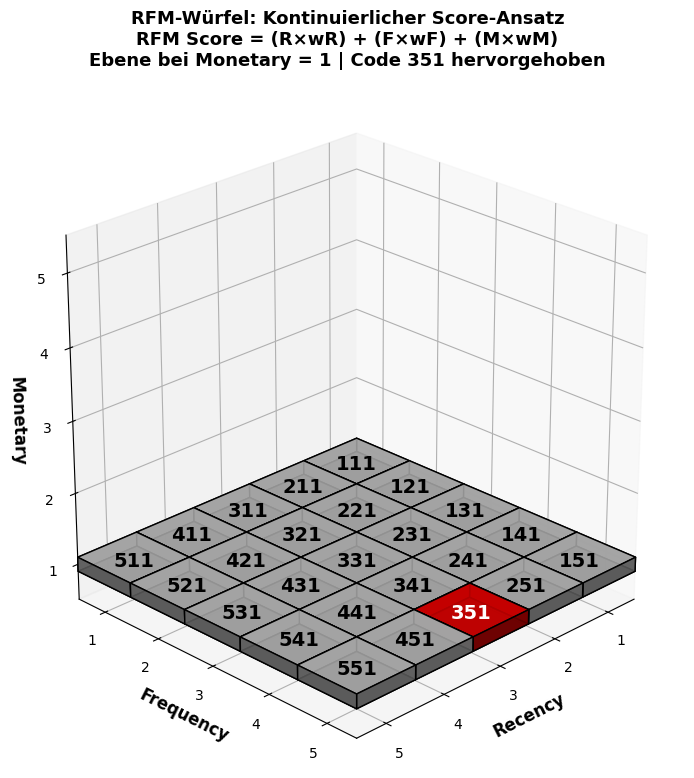

In [26]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# RFM-Dimensionen
recency_range = range(1, 6)     # 1-5
frequency_range = range(1, 6)   # 1-5
monetary_level = 1              # Feste Ebene bei Z=1

# Zeichne vollständige Ebene bei Monetary = 1
for r in recency_range:
    for f in frequency_range:
        code = f"{r}{f}{monetary_level}"

        # Hervorhebung für Code "351"
        if code == "351":
            color = "red"           # Besondere Hervorhebung in rot
            text_color = "white"    # Weiße Schrift auf rot
        else:
            color = "lightgrey"
            text_color = "black"    # Schwarze Schrift auf grau

        # Korrigierte Positionierung: x=r, y=f, z=monetary_level
        ax.bar3d(
            x=r-0.5, y=f-0.5, z=monetary_level-0.1,  # Startposition (Ecke des Würfels)
            dx=1, dy=1, dz=0.2,                       # Größe
            color=color, edgecolor='black', alpha=0.9  # Weniger transparent
        )

        # Text in der Mitte des Würfels platzieren - ALLE FETT UND GUT SICHTBAR
        ax.text(
            r, f, monetary_level + 0.05,  # Leicht über der Oberfläche
            code,
            color=text_color,
            ha='center', va='center',
            fontsize=14,               # Noch größere Schrift
            weight='bold',             # ALLE Texte fett
            zorder=100                 # Text immer im Vordergrund
        )

# Achsentitel (korrekte Zuordnung)
ax.set_xlabel("Recency", fontsize=12, weight='bold')
ax.set_ylabel("Frequency", fontsize=12, weight='bold') 
ax.set_zlabel("Monetary", fontsize=12, weight='bold')

# Achsenticks
ax.set_xticks(range(1, 6))
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticks(range(1, 6))
ax.set_yticklabels(['1', '2', '3', '4', '5'])
ax.set_zticks(range(1, 6))

# Achsgrenzen
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0.5, 5.5)
ax.set_zlim(0.5, 5.5)

# Seitenverhältnis & Perspektive
ax.set_box_aspect([1, 1, 1])  # Gleiche Proportionen
ax.view_init(elev=25, azim=45)  # Bessere Sicht
ax.grid(True)

# Neue aussagekräftige Überschrift mit RFM-Score Berechnung
ax.set_title("RFM-Würfel: Kontinuierlicher Score-Ansatz\n" +
             "RFM Score = (R×wR) + (F×wF) + (M×wM)\n" +
             "Ebene bei Monetary = 1 | Code 351 hervorgehoben", 
             fontsize=13, weight='bold', pad=20)

# Layout-Anpassung ohne Warnung
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.1)  # Mehr Platz für Titel
plt.show()

In [ ]:
# Alternative: Monetary-Wert als Parameter
def create_rfm_plot(monetary_value=1):
    """
    Erstellt RFM-Plot für einen bestimmten Monetary-Wert
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    recency = range(1, 6)
    frequency = range(1, 6)
    monetary = [monetary_value]  # Gewünschter Monetary-Wert
    
    R, F, M = np.meshgrid(recency, frequency, monetary, indexing='ij')
    rfm_labels = np.vectorize(lambda r, f, m: f"{r}{f}{m}")(R, F, M)
    
    x = R.flatten()
    y = F.flatten()
    z = M.flatten()
    labels = rfm_labels.flatten()
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(x, y, z, color='lightgreen', edgecolors='black', s=100)
    
    for xi, yi, zi, label in zip(x, y, z, labels):
        ax.text(xi, yi, zi, label, fontsize=10, ha='center', va='center')
    
    ax.set_xlabel('Recency')
    ax.set_ylabel('Frequency')
    ax.set_zlabel('Monetary')
    ax.set_xticks(list(recency))
    ax.set_yticks(list(frequency))
    ax.set_zticks([monetary_value])
    ax.set_title(f"RFM-Analyse (Monetary = {monetary_value})")
    
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_zlim(monetary_value-0.5, monetary_value+0.5)
    
    plt.tight_layout()
    plt.show()

# Beispiel: Plot für Monetary = 1
create_rfm_plot(1)

# Sie können auch andere Werte testen:
# create_rfm_plot(2)
# create_rfm_plot(3)